In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

In [ ]:
# 1. Load and Clean the Dataset
df = pd.read_csv('marketing_AB.csv')

# Drop the auxiliary index column
df = df.drop(columns=['Unnamed: 0'])

# Check for duplicates to ensure unique users
print(f"Total duplicates in user id: {df.duplicated(subset='user id').sum()}")

Total duplicates in user id: 0


In [ ]:
# 2. Exploratory Data Analysis (EDA)
# Calculate basic metrics for each test group
counts = df.groupby('test group')['converted'].agg(['sum', 'count'])
counts['conversion_rate'] = counts['sum'] / counts['count']

print("\n--- Conversion Rates by Group ---")
print(counts)


--- Conversion Rates by Group ---
              sum   count  conversion_rate
test group                                
ad          14423  564577         0.025547
psa           420   23524         0.017854


In [ ]:
# 3. Statistical Hypothesis Testing
# Prepare contingency table for Chi-Square test
contingency_table = pd.crosstab(df['test group'], df['converted'])
chi2, p_val_chi2, dof, expected = chi2_contingency(contingency_table)

# Alternative: Z-test for two proportions
ad_converted = counts.loc['ad', 'sum']
ad_total = counts.loc['ad', 'count']
psa_converted = counts.loc['psa', 'sum']
psa_total = counts.loc['psa', 'count']

z_stat, p_val_z = proportions_ztest(
    np.array([ad_converted, psa_converted]),
    np.array([ad_total, psa_total])
)

print(f"\n--- Statistical Test Results ---")
print(f"Chi-Square P-value: {p_val_chi2:.4f}")
print(f"Z-Test P-value:      {p_val_z:.4f}")


--- Statistical Test Results ---
Chi-Square P-value: 0.0000
Z-Test P-value:      0.0000


In [ ]:
# 4. Confidence Intervals (95%)
ci_ad = proportion_confint(ad_converted, ad_total, alpha=0.05, method='normal')
ci_psa = proportion_confint(psa_converted, psa_total, alpha=0.05, method='normal')

print(f"\n--- 95% Confidence Intervals ---")
print(f"Ad group:  {ci_ad}")
print(f"PSA group: {ci_psa}")


--- 95% Confidence Intervals ---
Ad group:  (0.0251349995427061, 0.025958119730661394)
PSA group: (0.016161914715211324, 0.019546298173753137)


Text(0, 0.5, 'Conversion Rate (Decimal)')

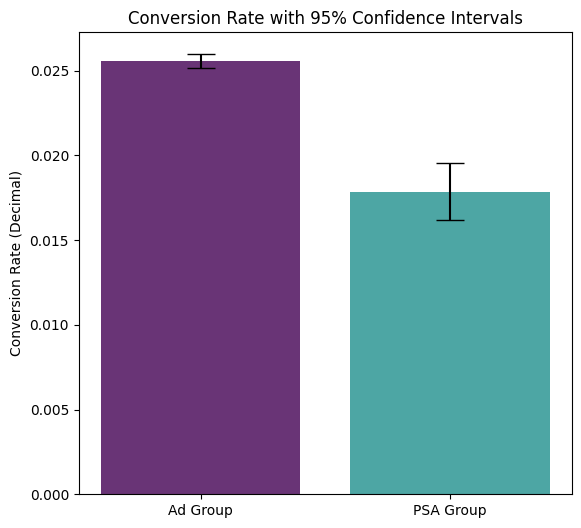

In [ ]:
# 5. Visualizations
plt.figure(figsize=(14, 6))

# Subplot 1: Bar chart with Error Bars (Confidence Intervals)
plt.subplot(1, 2, 1)
groups = ['Ad Group', 'PSA Group']
means = [counts.loc['ad', 'conversion_rate'], counts.loc['psa', 'conversion_rate']]
errors = [means[0] - ci_ad[0], means[1] - ci_psa[0]] # Error bar half-width

plt.bar(groups, means, color=['#440154', '#21908d'], alpha=0.8)
plt.errorbar(groups, means, yerr=errors, fmt='none', capsize=10, color='black', label='95% CI')
plt.title('Conversion Rate with 95% Confidence Intervals')
plt.ylabel('Conversion Rate (Decimal)')


/tmp/ipykernel_2367/335167988.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='most ads day', y='converted', order=day_order, palette='magma')


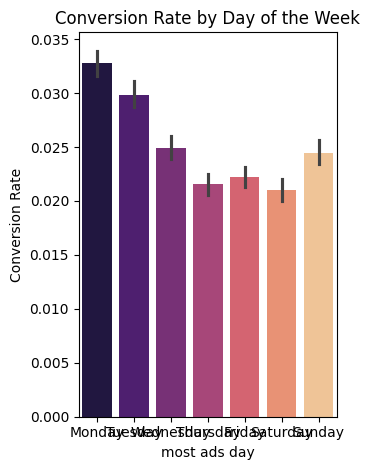

In [ ]:
# Subplot 2: Conversion by Day of Week
plt.subplot(1, 2, 2)
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.barplot(data=df, x='most ads day', y='converted', order=day_order, palette='magma')
plt.title('Conversion Rate by Day of the Week')
plt.ylabel('Conversion Rate')

plt.tight_layout()
plt.show()